Baixando dados, pode demorar...


C:\Users\henri\AppData\Local\Temp\ipykernel_37596\1478399179.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(markets_list, start=full_start, end=full_end, progress=True)
[*********************100%***********************]  15 of 15 completed



--- Tabela Final ---
               OPEN        CLOSE         HIGH          LOW        TTD  TTD(%)  \
Ticker                                                                          
^GSPC      6914.110     7041.280     7051.230     6316.910    127.170   1.839   
^IXIC     23548.881    24102.699    24156.180    20690.250    553.818   2.352   
^DJI      48850.172    48578.719    50512.789    45057.281   -271.453  -0.556   
^FTSE     10048.400    10590.000    10934.900     9670.500    541.600   5.390   
^GDAXI    25128.461    24154.471    25507.789    21863.811   -973.990  -3.876   
^N100      1758.150     1830.370     1858.660     1659.460     72.220   4.108   
^N225     51769.828    59518.340    59688.102    50558.910   7748.512  14.967   
^HSI      26302.779    26394.260    28056.100    24203.539     91.480   0.348   
^NSEI     26106.500    24196.750    26341.199    22182.551  -1909.750  -7.315   
^TWII     30330.580    37132.020    37135.551    29925.490   6801.439  22.424   
^STI  

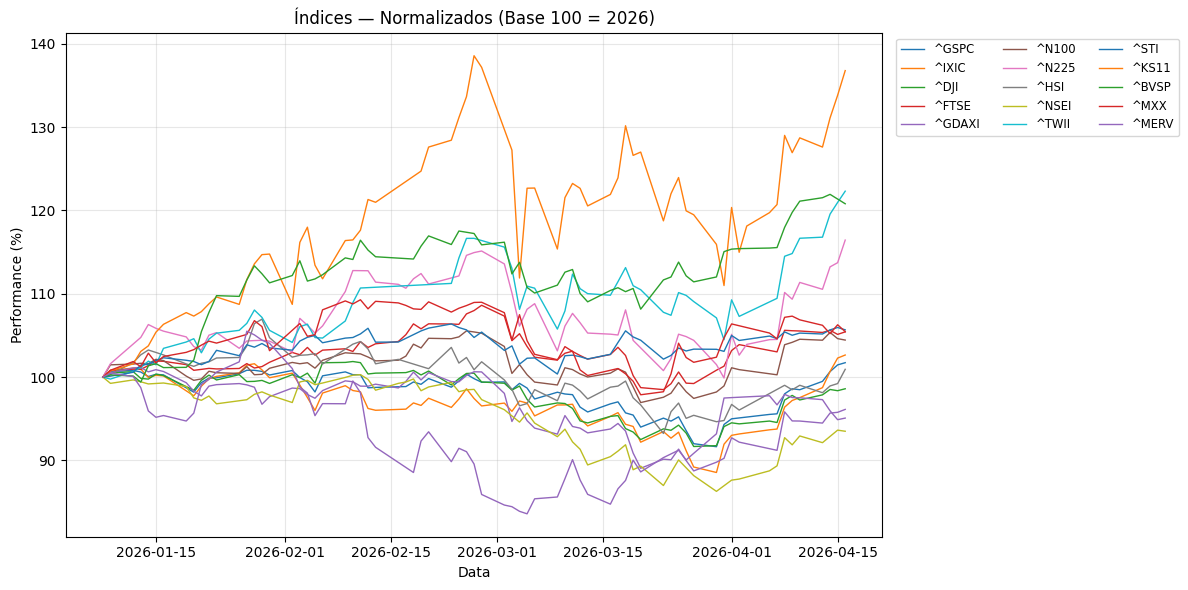

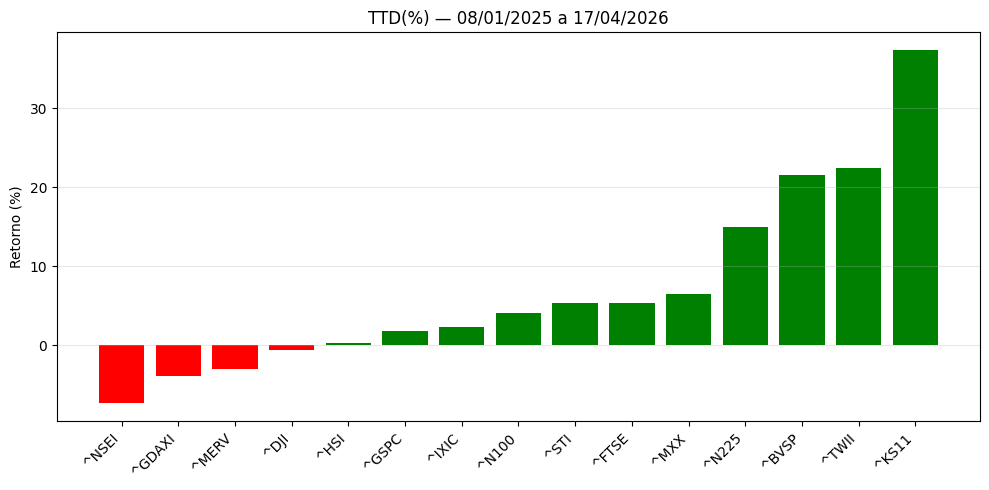

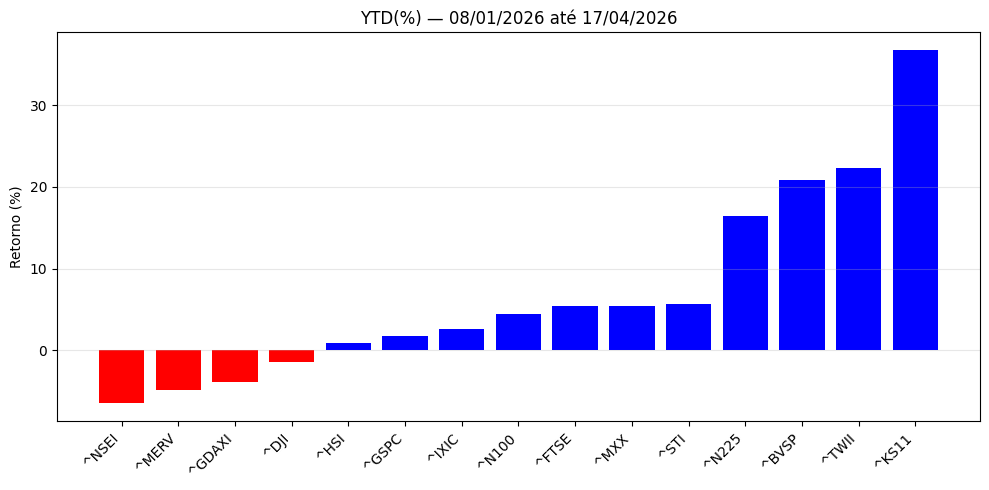

In [1]:
#Código sobre Markets (refere-se ao período do último trimestre de 2025)
#Para futuras utilizações, atualize o period_start, period_end, full_start, full_end e demais datas
#para a data de utilização. 

import yfinance as yf
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

markets_list = [
   '^GSPC', '^IXIC', '^DJI',
   '^FTSE', '^GDAXI','^N100',
   '^N225', '^HSI', '^NSEI', '^TWII', '^STI', '^KS11',
   '^BVSP', '^MXX', '^MERV'
]

#Períodos
period_start = '2026-01-08'
period_end = '2026-04-17'
y_ref_date = '2026-01-08'
full_start = '2025-01-08' 
full_end = '2026-04-17' 

print("Baixando dados, pode demorar...")
raw = yf.download(markets_list, start=full_start, end=full_end, progress=True)

if isinstance(raw.columns, pd.MultiIndex):
    open_df = raw['Open']
    high_df = raw['High']
    low_df = raw['Low']
    close_df = raw['Close']
else:
    open_df = raw['Open'] if 'Open' in raw.columns else pd.DataFrame()
    high_df = raw['High'] if 'High' in raw.columns else pd.DataFrame()
    low_df = raw['Low'] if 'Low' in raw.columns else pd.DataFrame()
    close_df = raw['Close'] if 'Close' in raw.columns else pd.DataFrame()

# --- Funções Auxiliares de Segurança

def safe_first_available(series, date_str):
    try: 
        s = series.loc[date_str:]
        if s.dropna().empty:
            return np.nan
        return s.dropna().iloc[0]
    except Exception:
        return np.nan
def safe_last_available(series, date_str):
    try:
        s = series.loc[:date_str]
        if s.dropna().empty:
            return np.nan
        return s.dropna().iloc[-1]
    except Exception:
        return np.nan
def try_re_download(ticker):
    """Tenta baixar individualmente se falhar no lote"""
    try:
        sub = yf.download(ticker, start=full_start, end=full_end, progress=False)
        if sub is None or sub.empty:
            return None
        return sub
    except Exception:
        return None

rows = []
for t in markets_list:
    if t in open_df.columns and t in close_df.columns:
        o = safe_first_available(open_df[t], period_start)
        h = high_df[t].loc[period_start:period_end].max() if (t in high_df.columns) else np.nan
        l = low_df[t].loc[period_start:period_end].min()  if (t in low_df.columns) else np.nan
        c = safe_last_available(close_df[t], period_end)
        c_ly = safe_last_available(close_df[t], y_ref_date)
    else:
        # Tenta re-download individual
        sub = try_re_download(t)
        if sub is not None and not sub.empty:
            try:
                o = safe_first_available(sub['Open'], period_start)
                h = sub['High'].loc[period_start:period_end].max()
                l = sub['Low'].loc[period_start:period_end].min()
                c = safe_last_available(sub['Close'], period_end)
                c_ly = safe_last_available(sub['Close'], y_ref_date)
            except Exception:
                o = h = l = c = c_ly = np.nan
        else:
            print(f"Warning: dados não encontrados para {t}. Marcando como NaN.")
            o = h = l = c = c_ly = np.nan
    rows.append({
        'Ticker': t,
        'OPEN': o, 'HIGH': h, 'LOW': l, 'CLOSE': c,
        'CLOSE_REF_YTD': c_ly # Nome genérico para referência
    })

df = pd.DataFrame(rows).set_index('Ticker')
# --- Cálculos Financeiros ---
# TTD: 01/10/2025 -> 08/01/2026
df['TTD'] = df['CLOSE'] - df['OPEN']
df['TTD(%)'] = df['TTD'] / df['OPEN'] * 100

# YTD: 08/01/2025 -> 08/01/2026
df['YTD'] = df['CLOSE'] - df['CLOSE_REF_YTD']
df['YTD(%)'] = df['YTD'] / df['CLOSE_REF_YTD'] * 100

# Arredondamento
cols_to_round = ['OPEN','HIGH','LOW','CLOSE','CLOSE_REF_YTD','TTD','TTD(%)','YTD','YTD(%)']
df[cols_to_round] = df[cols_to_round].round(3)

# Seleção final de colunas
df_out = df[['OPEN','CLOSE','HIGH','LOW','TTD','TTD(%)','YTD','YTD(%)','CLOSE_REF_YTD']]
print("\n--- Tabela Final ---")
print(df_out)

# Salvar Excel
out_file = "markets_adapted_2026.xlsx"
df_out.to_excel(out_file, index=True)
print(f"Planilha salva como: {out_file}")

# 1. Gráfico de Linha (Normalizado Year Over Year)
plt.figure(figsize=(12,6))
for t in markets_list:
    if t in close_df.columns:
        # Pega do início do YTD até o fim
        series = close_df[t].loc[y_ref_date:full_end].dropna()
    else:
        sub = try_re_download(t)
        series = sub['Close'].loc[y_ref_date:full_end].dropna() if sub is not None else pd.Series(dtype=float)
    
    if series.empty:
        continue
        
    # Normaliza base 100 na data de referência YTD
    base = safe_last_available(series, y_ref_date)
    if pd.isna(base) or base == 0:
        continue
    
    norm = series / base * 100
    plt.plot(norm.index, norm.values, label=t, linewidth=1)

plt.title("Índices — Normalizados (Base 100 = 2026)")
plt.ylabel("Performance (%)")
plt.xlabel("Data")
plt.legend(ncol=3, fontsize='small', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Gráfico de Barras TTD
plt.figure(figsize=(10,5))
valid_ttd = df_out['TTD(%)'].replace([np.inf, -np.inf], np.nan).dropna()
valid_ttd.sort_values(inplace=True)
colors_ttd = ['red' if x < 0 else 'green' for x in valid_ttd.values] # Adicionei cor condicional
plt.bar(valid_ttd.index, valid_ttd.values, color=colors_ttd)
plt.title("TTD(%) — 08/01/2025 a 17/04/2026")
plt.ylabel("Retorno (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Gráfico de Barras YTD
plt.figure(figsize=(10,5))
valid_ytd = df_out['YTD(%)'].replace([np.inf, -np.inf], np.nan).dropna()
valid_ytd.sort_values(inplace=True)
colors_ytd = ['red' if x < 0 else 'blue' for x in valid_ytd.values] # Adicionei cor condicional
plt.bar(valid_ytd.index, valid_ytd.values, color=colors_ytd)
plt.title("YTD(%) — 08/01/2026 até 17/04/2026")
plt.ylabel("Retorno (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Baixando dados Forex...


C:\Users\henri\AppData\Local\Temp\ipykernel_37596\842899428.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(pairs, start=start_full, end=end_full, progress=True)
[*********************100%***********************]  16 of 16 completed


Planilha salva em: forex_adapted_2026.xlsx


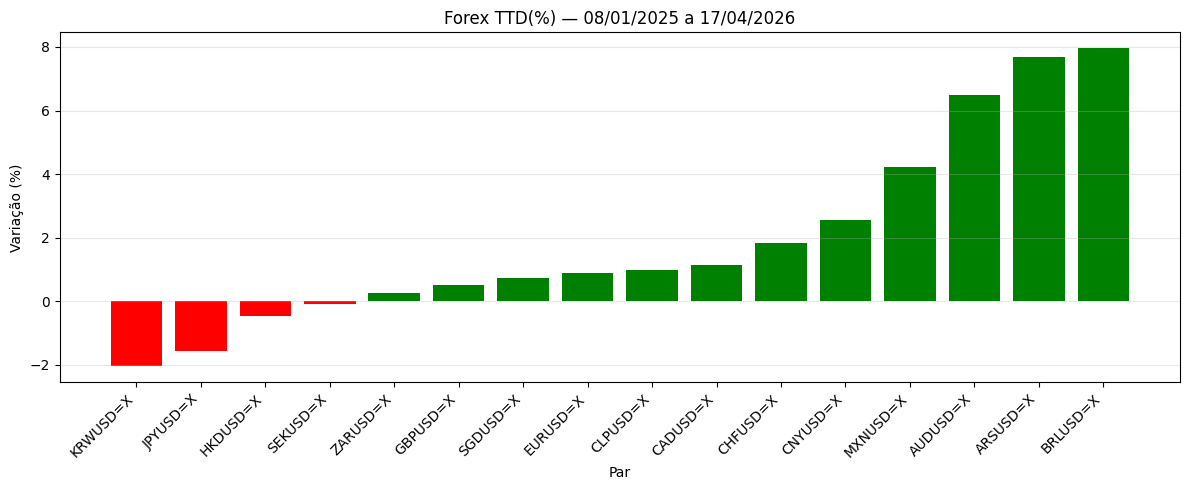

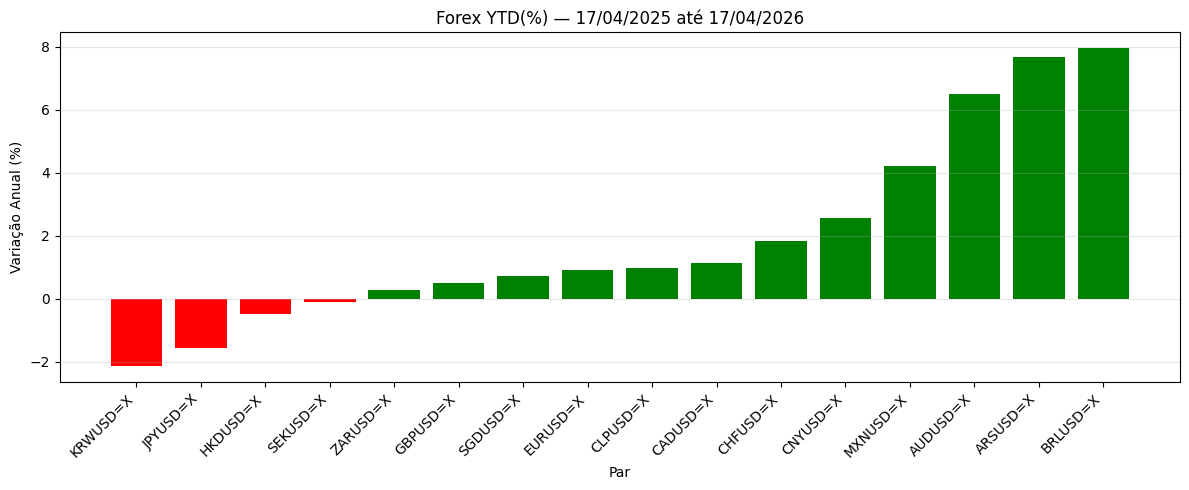

In [2]:
#Código sobre Forex

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

pairs = [
    'EURUSD=X','GBPUSD=X','CHFUSD=X','CADUSD=X','SEKUSD=X',
    'JPYUSD=X','AUDUSD=X','CNYUSD=X','SGDUSD=X','HKDUSD=X',
    'KRWUSD=X','BRLUSD=X','ARSUSD=X','CLPUSD=X','MXNUSD=X',
    'ZARUSD=X'
]

# --- Definição de Timeframes ---
# Período TTD (Time to Date)
start_period = '2026-01-08'
end_period   = '2026-04-17'

# Referência YTD (Year to Date - 1 ano exato neste caso)
ref_date_ytd = '2026-01-08'

# Range de Download (com margem de segurança)
# Começa um pouco antes da ref YTD e termina depois do fim do período
start_full = '2025-04-17'   
end_full   = '2026-04-17'

# Baixa dados
print("Baixando dados Forex...")
raw = yf.download(pairs, start=start_full, end=end_full, progress=True)

# Separar Open/High/Low/Close adequadamente
if isinstance(raw.columns, pd.MultiIndex):
    open_df = raw['Open']
    high_df = raw['High']
    low_df  = raw['Low']
    close_df= raw['Close']
else:
    open_df = raw['Open']
    high_df = raw['High']
    low_df  = raw['Low']
    close_df= raw['Close']

# Funções auxiliares
def first_available(series_df, date_str):
    # Pega a primeira data disponível a partir de date_str
    try:
        s = series_df.loc[date_str:]
        if s.empty: return None
        return s.iloc[0]
    except: return None

def last_available(series_df, date_str):
    # Pega a última data disponível até date_str
    try:
        s = series_df.loc[:date_str]
        if s.empty: return None
        return s.iloc[-1]
    except: return None

# Seleção de Dados
open_on_start = first_available(open_df, start_period) # 01/10/2025
high_in_range = high_df.loc[start_period:end_period].max()
low_in_range  = low_df.loc[start_period:end_period].min()
close_on_end  = last_available(close_df, end_period)   # 08/01/2026
close_ref_ytd = last_available(close_df, ref_date_ytd) # 08/01/2025

# Montar DataFrame
# Usamos o index do close_on_end para garantir alinhamento
df = pd.DataFrame({
    'Ticker': close_on_end.index,
    'OPEN': open_on_start.values,
    'HIGH': high_in_range.values,
    'LOW': low_in_range.values,
    'CLOSE': close_on_end.values,
    'CLOSE_REF_YTD': close_ref_ytd.values # Antigo CLOSE_2024
})

# Cálculos Financeiros
# TTD: 01/10/25 a 08/01/26
df['TTD'] = df['CLOSE'] - df['OPEN']
df['TTD(%)'] = df['TTD'] / df['OPEN'] * 100

# YTD: 08/01/25 a 08/01/26
df['YTD'] = df['CLOSE'] - df['CLOSE_REF_YTD']
df['YTD(%)'] = df['YTD'] / df['CLOSE_REF_YTD'] * 100

# Formatação (Forex precisa de mais casas decimais)
df[['OPEN','HIGH','LOW','CLOSE','CLOSE_REF_YTD']] = df[['OPEN','HIGH','LOW','CLOSE','CLOSE_REF_YTD']].round(6)
df[['TTD','YTD']] = df[['TTD','YTD']].round(6)
df[['TTD(%)','YTD(%)']] = df[['TTD(%)','YTD(%)']].round(2)

# Reorder e Salvar
df = df[['Ticker','OPEN','CLOSE','HIGH','LOW','TTD','TTD(%)','YTD','YTD(%)','CLOSE_REF_YTD']]
out_path = 'forex_adapted_2026.xlsx'
df.to_excel(out_path, index=False)
print(f"Planilha salva em: {out_path}")

# --- Plots ---

# Função simples para cor (Verde para alta, Vermelho para baixa)
def get_colors(values):
    return ['green' if v >= 0 else 'red' for v in values]

# Plot 1: TTD
plt.figure(figsize=(12,5))
plt.title("Forex TTD(%) — 08/01/2025 a 17/04/2026")
# Ordenar para ficar mais bonito visualmente
df_sorted_ttd = df.sort_values('TTD(%)')
plt.bar(df_sorted_ttd['Ticker'], df_sorted_ttd['TTD(%)'], color=get_colors(df_sorted_ttd['TTD(%)']))
plt.ylabel("Variação (%)")
plt.xlabel("Par")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: YTD
plt.figure(figsize=(12,5))
plt.title("Forex YTD(%) — 17/04/2025 até 17/04/2026")
df_sorted_ytd = df.sort_values('YTD(%)')
plt.bar(df_sorted_ytd['Ticker'], df_sorted_ytd['YTD(%)'], color=get_colors(df_sorted_ytd['YTD(%)']))
plt.ylabel("Variação Anual (%)")
plt.xlabel("Par")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import tradingeconomics as te
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURAÇÃO E AUTENTICAÇÃO
# ==========================================
# Insira sua chave da API aqui. 
# Se não tiver, crie em: https://developer.tradingeconomics.com/
te.login('SUA_API_KEY:SEU_API_SECRET') 

# ==========================================
# 2. MAPEAMENTO DE TICKERS
# ==========================================
# O Trading Economics usa nomes de países + maturidade, não códigos como "US10Y".
# Mapeamos o seu Ticker para o "Symbol" do TE e o País para a coluna da imagem.

bonds_map = {
    'US2Y':  {'symbol': 'United States 2 Year',  'country': 'United States'},
    'US5Y':  {'symbol': 'United States 5 Year',  'country': 'United States'},
    'US10Y': {'symbol': 'United States 10 Year', 'country': 'United States'},
    'US20Y': {'symbol': 'United States 20 Year', 'country': 'United States'},
    'JP10Y': {'symbol': 'Japan 10 Year',         'country': 'Japan'},
    'DE10Y': {'symbol': 'Germany 10 Year',       'country': 'Germany'},
    'CA10Y': {'symbol': 'Canada 10 Year',        'country': 'Canada'},
    'FR10Y': {'symbol': 'France 10 Year',        'country': 'France'},
    'GB10Y': {'symbol': 'United Kingdom 10 Year','country': 'United Kingdom'},
    'BR10Y': {'symbol': 'Brazil 10 Year',        'country': 'Brazil'},
    'IT10Y': {'symbol': 'Italy 10 Year',         'country': 'Italy'}
}

# ==========================================
# 3. DEFINIÇÃO DE DATAS
# ==========================================
# Time To Date (TTD)
ttd_start = '2026-01-01'
ttd_end   = '2026-04-17'

# Year Over Year (YOY) - Comparação com 1 ano antes do fim
yoy_ref   = '2026-04-17'

# Data inicial para download (pegar desde o YOY até o fim)
download_start = '2026-01-08'
download_end   = '2026-04-17'

# ==========================================
# 4. FUNÇÕES AUXILIARES
# ==========================================

def get_closest_value(df, target_date):
    """
    Encontra o valor na data exata ou no dia útil anterior mais próximo.
    """
    try:
        # Filtra dados até a data alvo
        subset = df.loc[:target_date]
        if subset.empty:
            return np.nan
        # Pega o último disponível (que será a data alvo ou anterior)
        return subset.iloc[-1]['close']
    except:
        return np.nan

rows = []

print("Iniciando coleta de dados via Trading Economics API...")

# ==========================================
# 5. LOOP DE COLETA E CÁLCULO
# ==========================================

for my_ticker, info in bonds_map.items():
    symbol_te = info['symbol']
    country   = info['country']
    
    print(f"Processando: {my_ticker} ({symbol_te})...")
    
    try:
        # Busca dados históricos
        # Retorna DataFrame com colunas: date, open, high, low, close
        data = te.getHistoricalData(symbol=symbol_te, initDate=download_start, endDate=download_end, output_type='df')
        
        if data is None or data.empty:
            print(f" -> Sem dados para {my_ticker}")
            rows.append({'COUNTRY': country, 'TICKER': my_ticker})
            continue

        # Ajuste de índice de data
        data['date'] = pd.to_datetime(data['date'])
        data = data.set_index('date').sort_index()
        
        # --- Coleta dos Pontos de Dados ---
        
        # 1. OPEN (Valor em 01/10/2025)
        val_open = get_closest_value(data, ttd_start)
        
        # 2. CLOSE (Valor em 08/01/2026)
        val_close = get_closest_value(data, ttd_end)
        
        # 3. Reference YOY (Valor em 08/01/2025)
        val_yoy_ref = get_closest_value(data, yoy_ref)
        
        # 4. HIGHEST / LOWEST (No intervalo do TTD: 01/10/25 a 08/01/26)
        # Filtra apenas o range do TTD
        period_data = data.loc[ttd_start:ttd_end]
        
        if not period_data.empty:
            val_highest = period_data['high'].max() # Usa coluna High se disponível, senão max do close
            val_lowest  = period_data['low'].min()
            
            # Fallback se a API retornar High/Low vazios (comum em yields, às vezes só vem close)
            if pd.isna(val_highest): val_highest = period_data['close'].max()
            if pd.isna(val_lowest):  val_lowest  = period_data['close'].min()
        else:
            val_highest = np.nan
            val_lowest = np.nan

        # --- Cálculos ---
        
        # TTD (Variação absoluta e %)
        ttd_abs = val_close - val_open
        ttd_pct = (ttd_abs / val_open) * 100 if val_open else np.nan
        
        # YOY (Variação absoluta e %)
        yoy_abs = val_close - val_yoy_ref
        yoy_pct = (yoy_abs / val_yoy_ref) * 100 if val_yoy_ref else np.nan

        # Adiciona à lista
        rows.append({
            'COUNTRY': country,
            'TICKER': my_ticker,
            'OPEN': val_open,
            'CLOSE': val_close,
            'HIGHEST': val_highest,
            'LOWEST': val_lowest,
            'TTD': ttd_abs,
            'TTD(%)': ttd_pct,
            'YOY': yoy_abs,       # Na sua imagem está escrito YOY (geralmente variação nominal)
            'YOY(%)': yoy_pct     # E YOY(%)
        })

    except Exception as e:
        print(f"Erro ao processar {my_ticker}: {e}")
        rows.append({'COUNTRY': country, 'TICKER': my_ticker})

# ==========================================
# 6. GERAÇÃO DA PLANILHA
# ==========================================

df_final = pd.DataFrame(rows)

# Ordenação das colunas conforme a imagem
cols_order = ['COUNTRY', 'TICKER', 'OPEN', 'CLOSE', 'HIGHEST', 'LOWEST', 'TTD', 'TTD(%)', 'YOY', 'YOY(%)']
df_final = df_final[cols_order]

# Formatação Opcional (Arredondamento)
numeric_cols = ['OPEN', 'CLOSE', 'HIGHEST', 'LOWEST', 'TTD', 'TTD(%)', 'YOY', 'YOY(%)']
df_final[numeric_cols] = df_final[numeric_cols].round(4)

print("\n--- Resultado Final ---")
print(df_final)

# Salvar
file_name = "bonds_tradingeconomics.xlsx"
df_final.to_excel(file_name, index=False)
print(f"\nPlanilha salva com sucesso: {file_name}")

Iniciando coleta de dados via Trading Economics API...
Processando: US2Y (United States 2 Year)...
Erro ao processar US2Y: getHistoricalData() got an unexpected keyword argument 'symbol'
Processando: US5Y (United States 5 Year)...
Erro ao processar US5Y: getHistoricalData() got an unexpected keyword argument 'symbol'
Processando: US10Y (United States 10 Year)...
Erro ao processar US10Y: getHistoricalData() got an unexpected keyword argument 'symbol'
Processando: US20Y (United States 20 Year)...
Erro ao processar US20Y: getHistoricalData() got an unexpected keyword argument 'symbol'
Processando: JP10Y (Japan 10 Year)...
Erro ao processar JP10Y: getHistoricalData() got an unexpected keyword argument 'symbol'
Processando: DE10Y (Germany 10 Year)...
Erro ao processar DE10Y: getHistoricalData() got an unexpected keyword argument 'symbol'
Processando: CA10Y (Canada 10 Year)...
Erro ao processar CA10Y: getHistoricalData() got an unexpected keyword argument 'symbol'
Processando: FR10Y (France 

KeyError: "['OPEN', 'CLOSE', 'HIGHEST', 'LOWEST', 'TTD', 'TTD(%)', 'YOY', 'YOY(%)'] not in index"

In [3]:
%pip install tradingeconomics

Note: you may need to restart the kernel to use updated packages.
